# Zonal Statistics for Administrative Regions

This tutorial demonstrates how to use the FAO OpenEO `zonal_stats` process to compute summary statistics over geographic zones. Zonal statistics are essential for reporting vegetation health, agricultural stress, or land conditions at district, province, or country scale.

**What you will learn:**
- How to use the FAO-specific `zonal_stats` process
- How to use the standard OpenEO `aggregate_spatial` process
- How to compute statistics (mean, min, max, sum, std) over polygons
- How to run categorical pixel counting
- How to work with multi-geometry FeatureCollections
- How to interpret metadata (area, pixel count, nominal scale)

**Prerequisites:**
- Completed the [Getting Started](01_getting_started.ipynb) tutorial
- `openeo`, `matplotlib`, `pandas` packages installed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/un-fao/openeo-docs/blob/main/tutorials/03_zonal_statistics.ipynb)

In [ ]:
# !pip install openeo matplotlib pandas numpy

## 1. Connect and Authenticate

In [2]:
import openeo
import json

# Connect to the FAO OpenEO backend
connection = openeo.connect("https://data.fao.org/openeo")

print(f"Connected to: {connection.root_url}")
print(f"API version: {connection.capabilities().api_version()}")

Connected to: https://data.fao.org/openeo/
API version: 1.2.0


In [3]:
# Authenticate via OIDC — this will open a browser window for FAO SSO login
connection.authenticate_oidc(provider_id="keycloak")

# Verify authentication
user_info = connection.describe_account()
print(f"Logged in as: {user_info}")

Authenticated using refresh token.
Logged in as: {'user_id': '2aec56d2-02dc-4538-be21-402932593fce', 'name': 'Abdallah Hadid', 'default_plan': None, 'storage': {'free': 107374155251, 'quota': 107374182400}, 'budget': None, 'links': []}


## 2. Define Administrative Zones

We define a FeatureCollection with multiple zones representing different sub-regions. In practice, these could be administrative boundaries, watersheds, or agricultural parcels.

In [9]:
# Define three zones in the Nile Delta region
zones = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Zone A — West", "district_id": 1},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [31.20, 30.00], [31.20, 30.05],
                    [31.25, 30.05], [31.25, 30.00],
                    [31.20, 30.00]
                ]]
            }
        },
        {
            "type": "Feature",
            "properties": {"name": "Zone B — Center", "district_id": 2},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [31.25, 30.00], [31.25, 30.05],
                    [31.30, 30.05], [31.30, 30.00],
                    [31.25, 30.00]
                ]]
            }
        },
        {
            "type": "Feature",
            "properties": {"name": "Zone C — East", "district_id": 3},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [31.30, 30.00], [31.30, 30.05],
                    [31.35, 30.05], [31.35, 30.00],
                    [31.30, 30.00]
                ]]
            }
        }
    ]
}

print(f"Defined {len(zones['features'])} zones:")
for f in zones["features"]:
    print(f"  - {f['properties']['name']} (ID: {f['properties']['district_id']})")

Defined 3 zones:
  - Zone A — West (ID: 1)
  - Zone B — Center (ID: 2)
  - Zone C — East (ID: 3)


## 3. Using `zonal_stats` — FAO Custom Process

The `zonal_stats` process is a FAO-specific extension that provides:
- Multiple statistics in a single call (mean, min, max, sum, std, var, count, range)
- Pixel metadata (masked/unmasked count, area in m², nominal scale)
- Categorical pixel counting mode

Let's compute vegetation statistics over our three zones.

In [ ]:
# Load VCI data for Q1 2020
cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent={
        "west": 31.2, "east": 31.35,
        "south": 30.0, "north": 30.1,
    },
    temporal_extent=["2020-01-01", "2020-06-01"],
)

# Reduce time dimension to get a single snapshot
mean_cube = cube.reduce_dimension(dimension="time", reducer="mean")

# Run zonal statistics with multiple stats
zonal_result = mean_cube.process(
    process_id="zonal_stats",
    arguments={
        "data_cube": mean_cube,
        "geometries": zones,
        "stats": ["mean", "min", "max", "std"],
    },
)

result = json.loads(zonal_result.save_result(format="JSON").download())
print(json.dumps(result, indent=2, default=str)[:2000])

[
  {
    "geometry": "geometry_0",
    "spatial_ref": 0,
    "variable": "mean",
    "value": 0.434530613,
    "name": "Zone A \u2014 West",
    "district_id": 1
  },
  {
    "geometry": "geometry_1",
    "spatial_ref": 0,
    "variable": "mean",
    "value": 0.4365306122,
    "name": "Zone B \u2014 Center",
    "district_id": 2
  },
  {
    "geometry": "geometry_2",
    "spatial_ref": 0,
    "variable": "mean",
    "value": 0.2955952376,
    "name": "Zone C \u2014 East",
    "district_id": 3
  },
  {
    "geometry": "geometry_0",
    "spatial_ref": 0,
    "variable": "min",
    "value": 0.1079999999,
    "name": "Zone A \u2014 West",
    "district_id": 1
  },
  {
    "geometry": "geometry_1",
    "spatial_ref": 0,
    "variable": "min",
    "value": 0.299,
    "name": "Zone B \u2014 Center",
    "district_id": 2
  },
  {
    "geometry": "geometry_2",
    "spatial_ref": 0,
    "variable": "min",
    "value": 0.1826666673,
    "name": "Zone C \u2014 East",
    "district_id": 3
  },
  {

## 4. Visualize Zonal Statistics

Let's create a comparison bar chart of the statistics across zones.

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Parse the flat list-of-records into a DataFrame and pivot: one row per zone, one column per stat
raw_df = pd.DataFrame(result)
stats_names = ["mean", "min", "max", "std"]

stats_df = raw_df[raw_df["variable"].isin(stats_names)]
df = stats_df.pivot_table(index="name", columns="variable", values="value", aggfunc="first")
df = df[stats_names].reset_index().rename(columns={"name": "zone"})

print(df.to_string(index=False))

           zone     mean      min      max      std
  Zone A — West 0.434531 0.108000 0.899333 0.144549
Zone B — Center 0.436531 0.299000 0.578000 0.079382
  Zone C — East 0.295595 0.182667 0.473667 0.072362


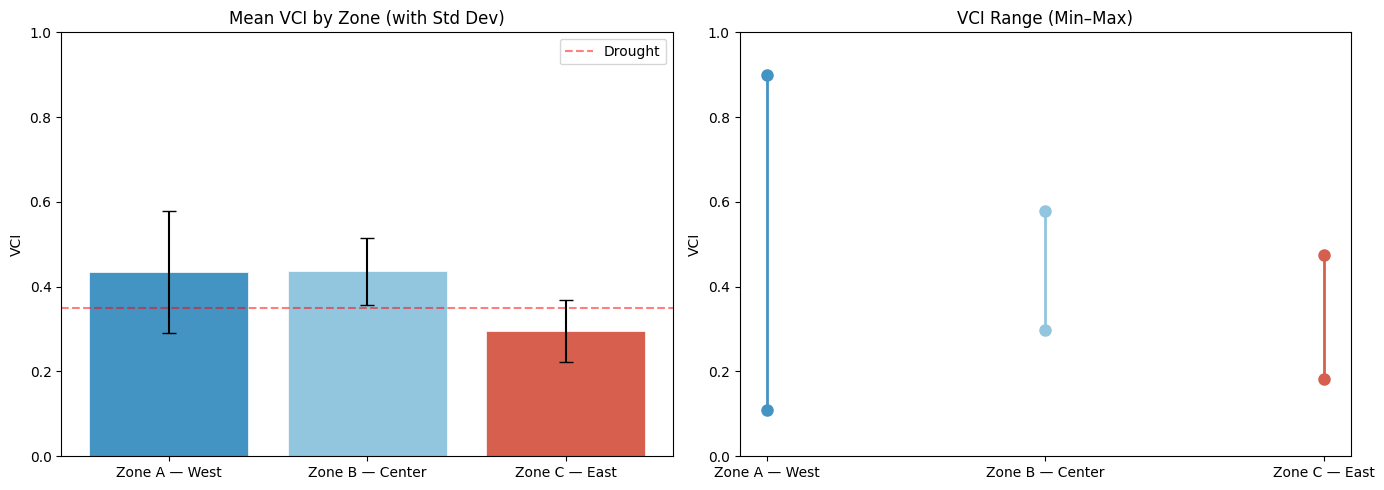

In [12]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#4393c3", "#92c5de", "#d6604d"]

# Plot 1: Mean VCI per zone with error bars (std)
bars = axes[0].bar(df["zone"], df["mean"], color=colors[:len(df)], edgecolor="white", linewidth=0.5)
if "std" in df.columns:
    axes[0].errorbar(df["zone"], df["mean"], yerr=df["std"],
                     fmt="none", ecolor="black", capsize=5)
axes[0].set_ylabel("VCI")
axes[0].set_title("Mean VCI by Zone (with Std Dev)")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.35, color="red", linestyle="--", alpha=0.5, label="Drought")
axes[0].legend()

# Plot 2: Min/Max range per zone
for i, (_, row) in enumerate(df.iterrows()):
    axes[1].plot([i, i], [row["min"], row["max"]], "o-",
                 color=colors[i % len(colors)], markersize=8, linewidth=2)
axes[1].set_xticks(range(len(df)))
axes[1].set_xticklabels(df["zone"])
axes[1].set_ylabel("VCI")
axes[1].set_title("VCI Range (Min–Max)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Using `aggregate_spatial` — Standard OpenEO Process

The standard OpenEO `aggregate_spatial` process uses a reducer callback. This is compatible with any OpenEO backend.

In [ ]:
# Load data
cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent={"west": 31.2, "east": 31.35, "south": 30.0, "north": 30.1},
    temporal_extent=["2020-01-01", "2020-03-01"],
)

# Aggregate spatially with mean reducer
agg_result = cube.aggregate_spatial(
    geometries=zones,
    reducer="mean",
)

result_agg = json.loads(agg_result.save_result(format="JSON").download())
print("aggregate_spatial result:")
print(json.dumps(result_agg, indent=2, default=str)[:1500])

aggregate_spatial result:
[
  {
    "time": "2020-01-01T00:00:00Z",
    "geometry": "geometry_0",
    "spatial_ref": 0,
    "variable": "data",
    "value": 0.4781632645,
    "item_id": "ASIS.VCI-D.2020-01-D1",
    "start_datetime": "2020-01-01T00:00:00Z",
    "end_datetime": "2020-01-10T00:00:00Z",
    "name": "Zone A \u2014 West",
    "district_id": 1
  },
  {
    "time": "2020-01-01T00:00:00Z",
    "geometry": "geometry_1",
    "spatial_ref": 0,
    "variable": "data",
    "value": 0.2907142857,
    "item_id": "ASIS.VCI-D.2020-01-D1",
    "start_datetime": "2020-01-01T00:00:00Z",
    "end_datetime": "2020-01-10T00:00:00Z",
    "name": "Zone B \u2014 Center",
    "district_id": 2
  },
  {
    "time": "2020-01-01T00:00:00Z",
    "geometry": "geometry_2",
    "spatial_ref": 0,
    "variable": "data",
    "value": 0.1897619056,
    "item_id": "ASIS.VCI-D.2020-01-D1",
    "start_datetime": "2020-01-01T00:00:00Z",
    "end_datetime": "2020-01-10T00:00:00Z",
    "name": "Zone C \u2014 East

## 6. Categorical Pixel Counting

The `zonal_stats` process supports categorical mode, which counts the number of pixels for each unique value within each zone. This is useful for land cover classification maps.

For this example, we'll use it with the ASI (Agricultural Stress Index) collection, which has discrete categorical values.

In [ ]:
# Load ASI data (Agricultural Stress Index)
asi_cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:ASI-A",
    spatial_extent={"west": 31.0, "east": 31.2, "south": 30.0, "north": 30.2},
    temporal_extent=["2019-01-01", "2021-01-01"],
)

# Reduce to a single time step
asi_last = asi_cube.reduce_dimension(dimension="time", reducer="last")

# Define a single zone for categorical analysis
analysis_zone = {
    "type": "Polygon",
    "coordinates": [[
        [31.0, 30.0], [31.0, 30.2],
        [31.2, 30.2], [31.2, 30.0],
        [31.0, 30.0]
    ]]
}

# Run categorical zonal stats
cat_result = asi_last.process(
    process_id="zonal_stats",
    arguments={
        "data_cube": asi_last,
        "geometries": analysis_zone,
        "categorical": True,
    },
)

result_cat = json.loads(cat_result.save_result(format="JSON").download())
print("Categorical result:")
print(json.dumps(result_cat, indent=2, default=str)[:1500])

/home/amshawky97/Work/analysis-monorepo/openeo_backend/.venv/lib/python3.10/site-packages/openeo/metadata.py:575: UserWarning: Unknown dimension type 'categorical'
  complain("Unknown dimension type {t!r}".format(t=dim_type))


Categorical result:
[
  {
    "geometry": "geometry_0",
    "SEASON": "GS1",
    "LCT": "LC-C",
    "spatial_ref": 0,
    "variable": "count",
    "value": {
      "0.5": 112,
      "9.0": 41,
      "15.0": 10,
      "15.5": 7,
      "25.5": 82,
      "38.0": 82,
      "50.0": 7
    }
  },
  {
    "geometry": "geometry_0",
    "SEASON": "GS1",
    "LCT": "LC-G",
    "spatial_ref": 0,
    "variable": "count",
    "value": {}
  },
  {
    "geometry": "geometry_0",
    "SEASON": "GS2",
    "LCT": "LC-C",
    "spatial_ref": 0,
    "variable": "count",
    "value": {
      "0.0": 17,
      "3.0": 108,
      "20.5": 41,
      "30.0": 5,
      "32.5": 48,
      "73.5": 7
    }
  },
  {
    "geometry": "geometry_0",
    "SEASON": "GS2",
    "LCT": "LC-G",
    "spatial_ref": 0,
    "variable": "count",
    "value": {}
  },
  {
    "geometry": "geometry_0",
    "SEASON": "GS1",
    "LCT": "LC-C",
    "spatial_ref": 0,
    "variable": "unmasked_count",
    "value": 529
  },
  {
    "geometry": "g

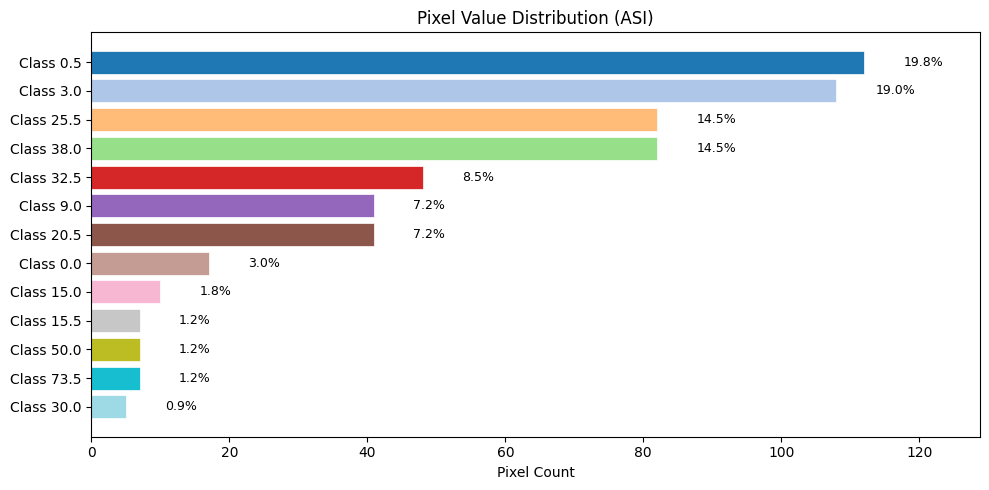

In [26]:
# Visualize categorical pixel counts as a horizontal bar chart
# The result is a list of records — one per geometry × SEASON × LCT combination.
# Records with empty value dicts have no pixels for that land cover type in the AOI.

from collections import Counter

count_totals = Counter()
for record in result_cat:
    if isinstance(record, dict) and record.get("variable") == "count":
        val = record.get("value", {})
        if isinstance(val, dict):
            for pixel_val, cnt in val.items():
                count_totals[pixel_val] += cnt

if count_totals:
    sorted_items = sorted(count_totals.items(), key=lambda x: x[1], reverse=True)
    labels = [f"Class {k}" for k, _ in sorted_items]
    values = [v for _, v in sorted_items]
    total = sum(values)
    pcts = [v / total * 100 for v in values]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_bar = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    bars = ax.barh(labels[::-1], values[::-1], color=colors_bar[::-1], edgecolor="white", linewidth=0.5)

    for bar, pct in zip(bars, pcts[::-1]):
        ax.text(bar.get_width() + total * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)

    ax.set_xlabel("Pixel Count")
    ax.set_title("Pixel Value Distribution (ASI)")
    ax.set_xlim(0, max(values) * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical counts found in result.")

## 7. Time Series Zonal Statistics

We can also compute zonal statistics across multiple time steps to track how conditions evolve within each zone.

In [ ]:
# Load a full year of data
cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent={"west": 31.2, "east": 31.35, "south": 30.0, "north": 30.1},
    temporal_extent=["2020-01-01", "2020-12-31"],
)

# Run zonal_stats on the full temporal cube
ts_zonal = cube.process(
    process_id="zonal_stats",
    arguments={
        "data_cube": cube,
        "geometries": zones,
        "stats": ["mean", "min", "max"],
    },
)

ts_result = json.loads(ts_zonal.save_result(format="JSON").download())
print("Multi-temporal zonal stats result:")
print(json.dumps(ts_result, indent=2, default=str)[:2000])

Multi-temporal zonal stats result:
[
  {
    "geometry": "geometry_0",
    "time": "2020-01-01T00:00:00Z",
    "spatial_ref": 0,
    "variable": "mean",
    "value": 0.4781632645,
    "item_id": "ASIS.VCI-D.2020-01-D1",
    "start_datetime": "2020-01-01T00:00:00Z",
    "end_datetime": "2020-01-10T00:00:00Z",
    "name": "Zone A \u2014 West",
    "district_id": 1
  },
  {
    "geometry": "geometry_0",
    "time": "2020-01-11T00:00:00Z",
    "spatial_ref": 0,
    "variable": "mean",
    "value": 0.5980612271,
    "item_id": "ASIS.VCI-D.2020-01-D2",
    "start_datetime": "2020-01-11T00:00:00Z",
    "end_datetime": "2020-01-20T00:00:00Z",
    "name": "Zone A \u2014 West",
    "district_id": 1
  },
  {
    "geometry": "geometry_0",
    "time": "2020-01-21T00:00:00Z",
    "spatial_ref": 0,
    "variable": "mean",
    "value": 0.6310204103,
    "item_id": "ASIS.VCI-D.2020-01-D3",
    "start_datetime": "2020-01-21T00:00:00Z",
    "end_datetime": "2020-01-31T00:00:00Z",
    "name": "Zone A \u20

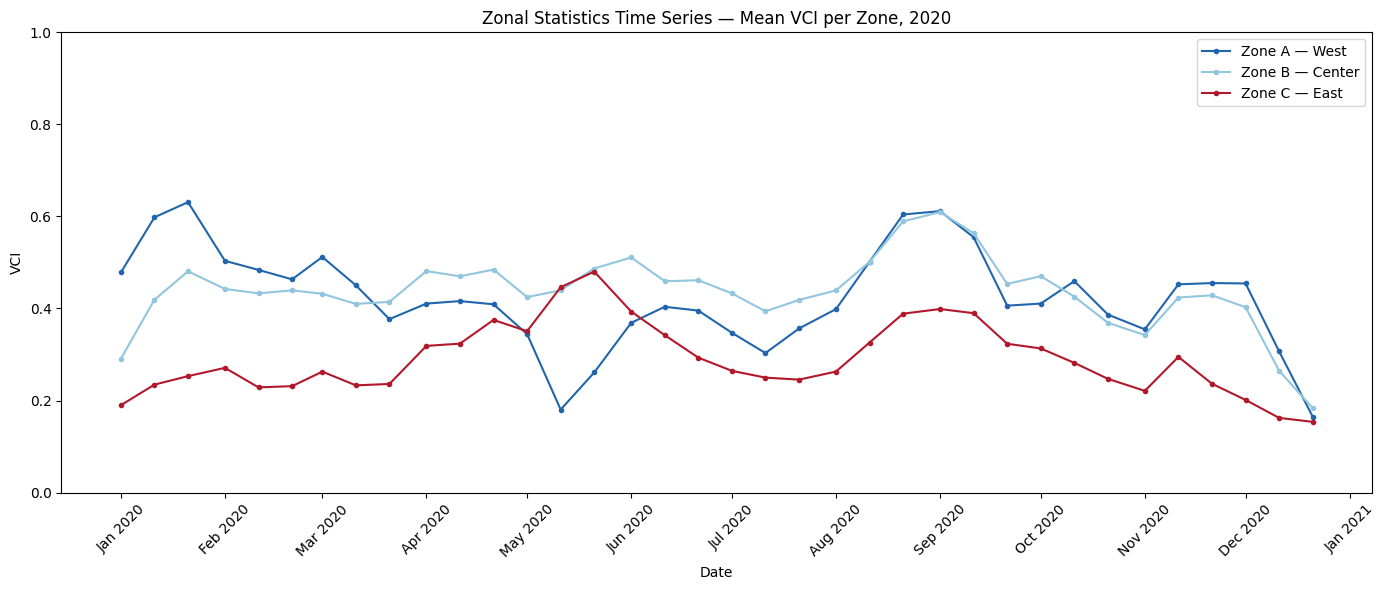

In [13]:
import matplotlib.dates as mdates

# Visualize multi-temporal zonal stats as a time series per zone
ts_df = pd.DataFrame(ts_result)
ts_df["time"] = pd.to_datetime(ts_df["time"])

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#2166ac", "#92c5de", "#b2182b"]

mean_df = ts_df[ts_df["variable"] == "mean"]
for idx, (zone_name, group) in enumerate(mean_df.groupby("name")):
    group = group.sort_values("time")
    color = colors[idx % len(colors)]
    ax.plot(group["time"], group["value"], marker="o", markersize=3, linewidth=1.5,
            color=color, label=zone_name)

ax.set_xlabel("Date")
ax.set_ylabel("VCI")
ax.set_title("Zonal Statistics Time Series — Mean VCI per Zone, 2020")
ax.legend()
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Interpreting Metadata Fields

The `zonal_stats` result includes useful metadata:

| Field | Description |
|-------|-------------|
| `unmasked_count` | Total number of pixels within the geometry |
| `masked_count` | Number of valid (non-NaN) pixels used in statistics |
| `area` | Area of the geometry in square meters (geodesic for geographic CRS) |
| `nominal_scale` | Ground distance per pixel in meters (accounts for latitude) |

These metadata fields help assess the reliability of the statistics — if `masked_count` is much lower than `unmasked_count`, many pixels were nodata.

In [24]:
# Display metadata for each zone
metadata_fields = ["unmasked_count", "masked_count", "area", "nominal_scale"]
zone_names = ["Zone A — West", "Zone B — Center", "Zone C — East"]

ts_df = pd.DataFrame(ts_result)

print(f"{'Zone':<25} {'Unmasked':>10} {'Masked':>10} {'Area (km²)':>12} {'Scale (m)':>10}")
print("-" * 70)

for zone_name in zone_names:
    zone_data = ts_df[ts_df["name"] == zone_name]
    row_vals = []
    for field in metadata_fields:
        field_data = zone_data[zone_data["variable"] == field]
        if not field_data.empty:
            row_vals.append(field_data["value"].iloc[0])
        else:
            row_vals.append("N/A")
    area_km2 = float(row_vals[2]) / 1e6 if row_vals[2] not in ("N/A", None) else "N/A"
    print(f"{zone_name:<25} {str(row_vals[0]):>10} {str(row_vals[1]):>10} "
          f"{str(area_km2):>12} {str(row_vals[3]):>10}")

Zone                        Unmasked     Masked   Area (km²)  Scale (m)
----------------------------------------------------------------------
Zone A — West                   49.0       49.0 26.822767653821074 860.5465265189
Zone B — Center                 49.0       49.0 26.822767653823284 860.5465265189
Zone C — East                   42.0       42.0 26.822767653823284 860.5465265189


## 9. Supported Statistics Reference

The `zonal_stats` process supports these statistics:

| Statistic | Description |
|-----------|-------------|
| `mean` | Arithmetic mean of pixel values |
| `min` | Minimum pixel value |
| `max` | Maximum pixel value |
| `sum` | Sum of all pixel values |
| `count` | Number of valid (non-NaN) pixels |
| `std` | Standard deviation |
| `var` | Variance |
| `range` | Difference between max and min |

Alternatively, set `categorical=True` (mutually exclusive with `stats`) to get pixel value histograms.

## Summary

In this tutorial, you learned how to:

1. **Use `zonal_stats`** to compute multiple statistics over polygons in a single call
2. **Use `aggregate_spatial`** for standard OpenEO-compatible spatial aggregation
3. **Run categorical analysis** to count pixel values within zones
4. **Interpret metadata** (area, pixel counts, nominal scale) to assess result quality
5. **Visualize** zonal statistics as bar charts and comparison plots

### Key Differences: `zonal_stats` vs `aggregate_spatial`

| Feature | `zonal_stats` | `aggregate_spatial` |
|---------|--------------|--------------------|
| Standard OpenEO | No (FAO extension) | Yes |
| Multiple stats at once | Yes | No (one reducer) |
| Area / pixel metadata | Yes | No |
| Categorical mode | Yes | Via `pixel_count` reducer |
| Portability | FAO backend only | Any OpenEO backend |

### Next Steps

- **[Climate Risk Assessment](04_climate_risk_crtb.ipynb)** — Run CRTB analyses for hazard and vulnerability mapping
- **[Planting Recommendations](05_planting_recommendations.ipynb)** — Agricultural planning with PLAN-T